In [1]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from cnn import ConvolutionalNeuralNetwork, Slicer, Reshape, Permute
import torch.nn as nn
import numpy as np
import pandas as pd


In [2]:
path = 'C:/Users/rober/OneDrive/Desktop/CS7150/CS7180-Final/data/annotations/vectorized-video-frames-labelled.dat'
data = np.memmap(path, dtype='float16', mode='r', shape=(3810, 5, 128, 128, 13))

X = data[:, :, :, :, :8]   # Shape (N, 5, 128, 128, 4), where 4 is the 3 color channels + the cls pedestrian or traffic light
y = data[:, :, 0, 0, 8:12] # Shape (N, 5, 5*), where 5* is the 4 of behavioural features + 5th is GPS speed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:

layers = [
    # Get the first 4 channels (RGB + pedestrian/traffic light)
    Slicer((slice(None), slice(None), slice(None), slice(None), slice(0, 4))), 
    Reshape((-1, 128, 128, 4)), 
    Permute((0, 3, 1, 2)),

    # Layer 1: Input is (8, 128, 128)
    nn.Conv2d(4, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2), # Output: (32, 64, 64)

    # Layer 2
    nn.Conv2d(32, 64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2), # Output: (64, 32, 32)

    # Layer 3
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2), # Output: (128, 16, 16)

    # Layer 4: Flatten for the dense layers
    nn.Flatten(), # Output: 128 * 16 * 16 = 32768
    
    # Layer 5: Fully Connected
    nn.Linear(32768, 512),
    nn.ReLU(),
    nn.Dropout(0.3), # Prevent overfitting on small pedestrian crops

    # Layer 6: Regression Head
    nn.Linear(512, 4),

    Reshape((-1, 5, 4))
]

model = ConvolutionalNeuralNetwork(
    layers=layers,
    epoch=100,
    learning_rate=0.001,
    batch_size=100,
    criterion='MSELoss',
    passthrough=slice(4, 8)
)

model.fit(X_train, y_train)

Training CNN: 100%|██████████| 100/100 [08:30<00:00,  5.10s/it, loss=0.0144]


,epoch,100
,learning_rate,0.001
,layers,Sequential( ...): Reshape() )
,criterion,'MSELoss'
,optimizer,'Adam'
,batch_size,100
,minimum_change,0.0
,seed,0
,passthrough,"slice(4, 8, None)"


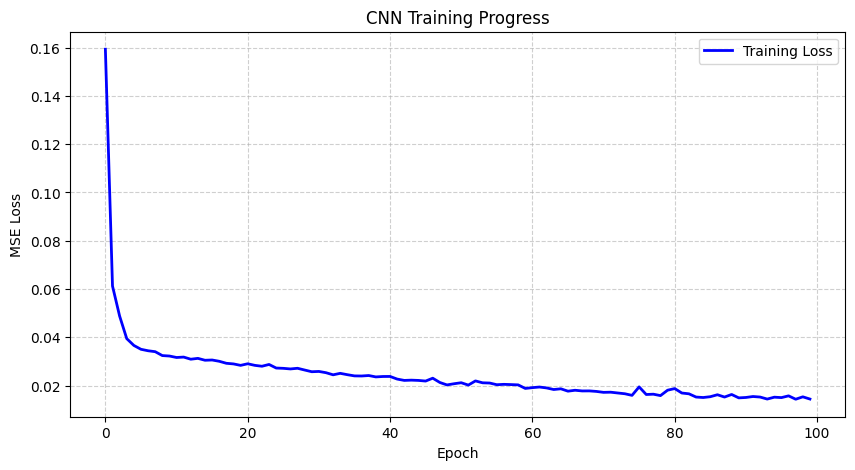

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(model.losses, label='Training Loss', color='blue', linewidth=2)
plt.title('CNN Training Progress')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [5]:
y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score, recall_score

# Flatten both arrays to (N*5, 4)
true_flat = y_test.reshape(-1, y_test.shape[-1])
pred_flat = y_pred.reshape(-1, y_pred.shape[-1])[:, 4:8]

results = []

labels  = ['Traffic light state', 'Pedestrian gesture', 'Pedestrian crossing', 'Pedestrian looking']
for label, i in zip(labels, range(4)):
    y_t = true_flat[:, i]
    y_p = pred_flat[:, i]
    
    # Round the raw regression output to the nearest flag integer
    y_p_rounded = np.round(y_p).astype(int)
    
    # Calculate scores
    mae = mean_absolute_error(y_t, y_p)
    acc = accuracy_score(y_t, y_p_rounded)
    prec = precision_score(y_t, y_p_rounded, average='macro', zero_division=0)
    rec = recall_score(y_t, y_p_rounded, average='macro', zero_division=0)
    results.append({
        "Flag": label,
        "Accuracy": f"{acc * 100:.1f}%",
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

pd.DataFrame(results)

,Flag,Accuracy,Precision,Recall
0,Traffic light state,97.8%,0.7729,0.9038
1,Pedestrian gesture,100.0%,0.4999,0.5000
2,Pedestrian crossing,97.5%,0.7178,0.4905
3,Pedestrian looking,96.1%,0.8906,0.6209


In [14]:
import pickle

# Save the model to a file
with open('pedestrian_behavior_or_trafficlight_state_cnn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

```python
# Load the model back into memory
with open('pedestrian_behavior_or_trafficlight_state_cnn_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
```